1. Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. Load the Apple dataset

In [ ]:
df = None

try:
    df = pd.read_csv("/content/drive/MyDrive/MachineLearningModels/Supervised Learning/stockmarketdataset/AAPL.csv")
    print("AAPL dataset loaded successfully.")
except FileNotFoundError:
    print("AAPL.csv was not found at the specified path.")

if df is not None:
    print("Displaying the first 5 rows:")
    display(df.head())

    print("\nDataFrame Information:")
    df.info()

    print("\nMissing values per column:")
    display(df.isnull().sum())

AAPL dataset loaded successfully.
Displaying the first 5 rows:


,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400



DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9909 entries, 0 to 9908
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9909 non-null   object 
 1   Open       9909 non-null   float64
 2   High       9909 non-null   float64
 3   Low        9909 non-null   float64
 4   Close      9909 non-null   float64
 5   Adj Close  9909 non-null   float64
 6   Volume     9909 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 542.0+ KB

Missing values per column:


,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


3. Check the shape

In [ ]:
df.shape

(9909, 7)

4. Convert Date to datetime

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

5. Sort by date

In [ ]:
df = df.sort_values('Date')
df = df.reset_index(drop=True)

6. Handle missing values

Your uploaded dataset has no missing values, but keeping this step makes the project more complete.

In [ ]:
df = df.ffill()

7. Create Year, Month, and Day

In [ ]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

8. Calculate daily return

In [ ]:
df['Daily_Return'] = df['Adj Close'].pct_change()

9. Calculate 10-day moving average

In [ ]:
df['Moving_Average_10'] = df['Adj Close'].rolling(window=10).mean()

10. Create the prediction target

In [ ]:
df['Target_Next_Day_Close'] = df['Adj Close'].shift(-1)

11. Remove rows created by calculations

In [ ]:
df = df.dropna()
df = df.reset_index(drop=True)

12. Define X and y

In [ ]:
y = df['Target_Next_Day_Close']
#features
X = df[
    [
        'Open',
        'High',
        'Low',
        'Close',
        'Adj Close',
        'Volume',
        'Year',
        'Month',
        'Day',
        'Daily_Return',
        'Moving_Average_10'
    ]
]

13. Split the data

For stock data, I recommend not using train_test_split() randomly.

Instead, use the first 80% for training and the last 20% for testing.

In [ ]:
split_index = int(len(df) * 0.80)
print(len(df))
print(split_index)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

9899
7919


14. Scale the features

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

15. Train Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

LinearRegression()

16. Make predictions

In [ ]:
y_pred_linear = linear_model.predict(X_test_scaled)

17. Calculate Linear Regression performance

In [ ]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

r2_linear = r2_score(y_test, y_pred_linear)

mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))

18. Display the results

In [ ]:
print("Linear Regression Results")
print("R² Score:", r2_linear)
print("MAE:", mae_linear)
print("RMSE:", rmse_linear)

Linear Regression Results
R² Score: 0.9977414022097033
MAE: 1.5792757578426955
RMSE: 2.8521060763476886


19. Random Forest Regression

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
#Make predictions
y_pred_rf = rf_model.predict(X_test)
#Calculate results
r2_rf = r2_score(y_test, y_pred_rf)

mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("Random Forest Results")
print("R² Score:", r2_rf)
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

Random Forest Results
R² Score: -0.7253457052216383
MAE: 54.55777565434003
RMSE: 78.8286861187079


20.  **SVR**

In [ ]:
from sklearn.svm import SVR

svr_model = SVR()

svr_model.fit(X_train_scaled, y_train)
#Predictions
y_pred_svr = svr_model.predict(X_test_scaled)
#Calculate results
r2_svr = r2_score(y_test, y_pred_svr)

mae_svr = mean_absolute_error(y_test, y_pred_svr)

rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
print("SVR Results")
print("R² Score:", r2_svr)
print("MAE:", mae_svr)
print("RMSE:", rmse_svr)

SVR Results
R² Score: -3.2301610003982377
MAE: 100.24816762348865
RMSE: 123.43112090189452


21. Compare all models

In [ ]:
model_results = {
    'Linear Regression': [r2_linear, mae_linear, rmse_linear],
    'Random Forest': [r2_rf, mae_rf, rmse_rf],
    'SVR': [r2_svr, mae_svr, rmse_svr]
}

results_df = pd.DataFrame(
    model_results,
    index=['R² Score', 'MAE', 'RMSE']
)

results_df = results_df.T

display(results_df)

,R² Score,MAE,RMSE
Linear Regression,0.997741,1.579276,2.852106
Random Forest,-0.725346,54.557776,78.828686
SVR,-3.230161,100.248168,123.431121


22. Plot actual vs predicted

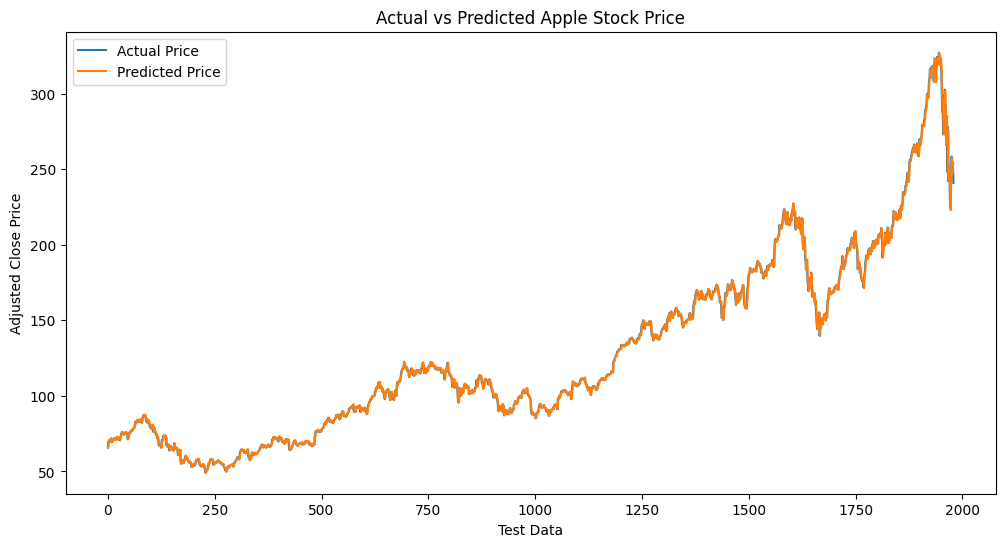

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(y_test.values, label='Actual Price')
plt.plot(y_pred_linear, label='Predicted Price')

plt.title('Actual vs Predicted Apple Stock Price')
plt.xlabel('Test Data')
plt.ylabel('Adjusted Close Price')

plt.legend()
plt.show()

I would not try to force the model to reach 85% accuracy like you did with Titanic.

For this Apple project, accuracy isn't the correct metric because the target is a continuous price.

Your main metrics are:

R² → higher is better
MAE → lower is better
RMSE → lower is better


